# Часть 1

🐾Парсинг сайтов со статьями, для того, чтобы узнать целевую аудиторию нашего проекта

In [16]:
import re
import requests
from bs4 import BeautifulSoup


def get_text_from_the_page(url):
    headers = {'User-Agent': 'Mozilla/5.0'}

    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, 'html.parser')
    return soup.get_text(' ', strip=True)


def match_percent_after_keyword(text, keyword):
    pattern = rf'{keyword}[^.]*?(\d+)\s*%'
    match = re.search(pattern, text, re.IGNORECASE)

    if match:
        return int(match.group(1))
    return None


def match_percent_before_keyword(text, keyword):
    pattern = rf'(\d+)\s*%[^.]*?{keyword}'
    match = re.search(pattern, text, re.IGNORECASE)

    if match:
        return int(match.group(1))
    return None


url = 'https://wciom.ru/analytical-reviews/analiticheskii-obzor/koshki-sobaki-i-vse-vse-vse'

text = get_text_from_the_page(url)

cats = match_percent_after_keyword(text, 'кошка')
dogs = match_percent_after_keyword(text, 'собака')
total = match_percent_before_keyword(text, 'россиян владеют домашними животными')


print(f'''{total}% россиян владеют домашними животными
Кошек из них: {cats}%
Собак из них: {dogs}%''')

70% россиян владеют домашними животными
Кошек из них: 79%
Собак из них: 48%


Построила графичек, чтобы нагляднее

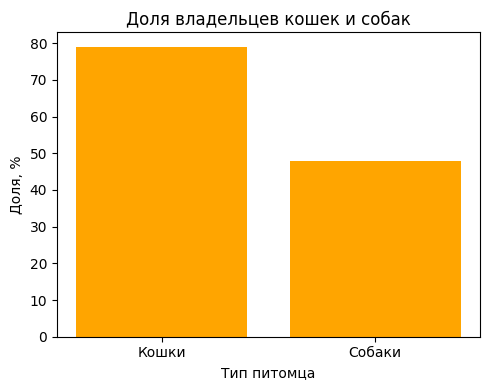

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

audience_df = pd.DataFrame({
    'animal': ['Кошки', 'Собаки'],
    'percent': [cats, dogs]})

plt.figure(figsize=(5, 4))
plt.bar(audience_df['animal'], audience_df['percent'], color='orange')
plt.title('Доля владельцев кошек и собак')
plt.xlabel('Тип питомца')
plt.ylabel('Доля, %')
plt.tight_layout()
plt.show()

🐾На основе этих данных мы пришли к выводу, что большинство россиян держат **кошек**, как домашних животных, но также большую часть занимают и **собаки**. Поэтому наш проект будет, в основном, направлен на эти две категории

# Часть 2

🐾Парсим данные (определяем популярные запросы держателей домашних животных по количеству упоминаний) для того, чтобы определить боли клиентов, и можно было сказать какие приблизительно сервисы у нас будут (учитываем, что выборки тут немного смещенные, так как данные взяты с четырех форумов)

In [18]:
import requests
from bs4 import BeautifulSoup
import re


class ForumParser:
    def __init__(self, urls, keywords):
        self.urls = urls
        self.keywords = keywords

    def get_page_text(self, url):
        headers = {'User-Agent':'Mozilla/5.0'}
        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')

        return soup.get_text(' ', strip=True)

    def collect_text(self):
        text=' '

        for url in self.urls:
            text += self.get_page_text(url)
        return text


    def parse(self):
        text=self.collect_text()

        counter={}

        for word in self.keywords:
          matches=re.findall(word, text, re.IGNORECASE)
          counter[word]=len(matches)

        return counter

keywords = [
    #Услуги
    'передерж',
    'присмотр',
    'выгул',
    'груминг',
    'няня',
    'сиделка',
    'догситтер',

    #Ситуации
    'отпуск',
    'поездк',
    'командировк',
    'уезж',
    'остав',
    'некому',
    'некого',
    'дома один',
    'один',

    #Тревоги
    'пережив',
    'страшн',
    'трево',
    'довер',
    'надежн',
    'провер',

    #Уход
    'уход',
    'кормление',
    'здоровье',
    'ветеринар',
    'лечение',

    #Типы животных
    'кошк',
    'собак',
    'попуг',
    'хомяк',
    'крыс',
    'крол',
    'рыб',
    'черепах',
    'грызун',

    #Потребности животных
    'игра',
    'гулят',
    'дрессиров',
    'воспит']


urls = ['https://animals.moe-online.ru/forum',
        'https://www.spbtalk.ru/forums/19/',
        'https://lapkins.ru/forum/']


forum = ForumParser(urls, keywords)
results = forum.parse()

for key,value in sorted(results.items(), key=lambda x:x[1], reverse=True):
  print(key, value)

собак 30
кошк 28
грызун 6
остав 5
хомяк 4
рыб 4
ветеринар 3
передерж 2
уход 2
попуг 2
дрессиров 2
груминг 1
кормление 1
лечение 1
крыс 1
игра 1
воспит 1
присмотр 0
выгул 0
няня 0
сиделка 0
догситтер 0
отпуск 0
поездк 0
командировк 0
уезж 0
некому 0
некого 0
дома один 0
один 0
пережив 0
страшн 0
трево 0
довер 0
надежн 0
провер 0
здоровье 0
крол 0
черепах 0
гулят 0


Графичек, для наглядности

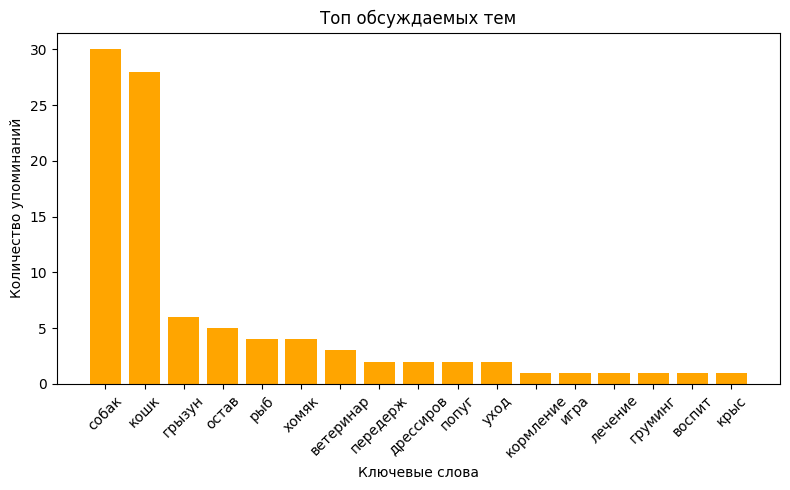

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df_forum = pd.DataFrame(results.items(), columns=['keyword', 'count'])
df_forum = df_forum.sort_values('count', ascending=False)

top = df_forum.head(17)

plt.figure(figsize=(8, 5))

plt.bar(top['keyword'], top['count'], color='orange')

plt.title('Топ обсуждаемых тем')
plt.xlabel('Ключевые слова')
plt.ylabel('Количество упоминаний')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

🐾 На основе графика, можно сделать вывод, что большинство людей волнуют собаки, так как за ними нужно больше следить, однако, кошки и другие зверьки тоже встречаются часто, соответственно, наш бизнес проект должен включать заботу не только о кошках и собаках, но и о рыбках или грызунах.

 🐾Большая чать людей не знает, где можно оставить своих питомцев, например, на время отдыха, поэтому наш сервис также сделает рекламу, направленную на освещение этого вопроса и доступность, а также прозрачность условий содержания в нашем пет френдли уголке.

 🐾Ветеринары, кинологи, грумеры и другие важные сервисы, также будут предсмотрены нашим проектом.

# Часть 3

🐾Смотрим(парсим) популярные методы маркетинга с разных источников(статей) и выделяем те, которые наиболее популярны (то есть встречаются чаще)

In [20]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd


class MarketingMethodsParser:

    def __init__(self, sources, methods):
        self.sources = sources
        self.methods = methods

    def get_page_text(self, url):
        headers = {'User-Agent': 'Mozilla/5.0'}

        response = requests.get(url, headers=headers, timeout=20)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, 'html.parser')
        return soup.get_text(' ', strip=True).lower()

    #Если наешл keyword возвращает 1
    def check_method_in_text(self, text, keywords):
        for keyword in keywords:
            if re.search(keyword.lower(), text):
                return 1
        return 0

    def parse(self):
        rows = []

        for source_name, url in self.sources.items():
            text = self.get_page_text(url)

            for method_name, keywords in self.methods.items():
                is_found = self.check_method_in_text(text, keywords)

                rows.append({
                    'source': source_name,
                    'method': method_name,
                    'is_found': is_found})

        return pd.DataFrame(rows)

sources = {
    'Sidorin Lab': 'https://sidorinlab.ru/blog/9-universalnyix-smm-instrumentov-dlya-prodvizheniya-biznesa',
    'MBSchool': 'https://mbschool.ru/faq/articles/kanaly-prodvizheniya-v-marketinge/',
    'OKOCRM': 'https://okocrm.com/blog/kontent-marketing-dlya-malogo-biznesa/',
    'SberBusiness': 'https://sberbusiness.live/publications/ugc-content'}

methods = {'Таргетированная реклама': [r'таргет', r'таргетированн'],
           'Контент-маркетинг': [r'контент-маркетинг', r'контент'],
           'Видео': [r'видео', r'shorts', r'reels', r'ролик', r'тикток', r'tiktok'],
           'UGC': [r'ugc', r'пользовательск'],
           'Инфлюенсеры': [r'инфлюенсер', r'блогер', r'знаменитость'],
           'Отзывы': [r'отзыв', r'рекомендац'],
           'Акции и промокоды': [r'акци', r'промокод', r'скидк'],
           'Email-рассылки': [r'email', r'рассылк'],
           'SEO': [r'seo',r'поисков']}

parser = MarketingMethodsParser(sources=sources, methods=methods)

df_methods_raw = parser.parse()

print(df_methods_raw.to_string(index=False))

      source                  method  is_found
 Sidorin Lab Таргетированная реклама         1
 Sidorin Lab       Контент-маркетинг         1
 Sidorin Lab                   Видео         1
 Sidorin Lab                     UGC         1
 Sidorin Lab             Инфлюенсеры         1
 Sidorin Lab                  Отзывы         1
 Sidorin Lab       Акции и промокоды         1
 Sidorin Lab          Email-рассылки         1
 Sidorin Lab                     SEO         0
    MBSchool Таргетированная реклама         1
    MBSchool       Контент-маркетинг         1
    MBSchool                   Видео         1
    MBSchool                     UGC         1
    MBSchool             Инфлюенсеры         0
    MBSchool                  Отзывы         1
    MBSchool       Акции и промокоды         1
    MBSchool          Email-рассылки         1
    MBSchool                     SEO         1
      OKOCRM Таргетированная реклама         1
      OKOCRM       Контент-маркетинг         1
      OKOCRM 

In [21]:
#Группируем по методам, суммируем, сортируем
df_methods = (df_methods_raw.groupby("method")["is_found"].sum().reset_index().sort_values("is_found", ascending=False))

df_methods = df_methods.rename(columns={"is_found": "sources_count"})
print(df_methods.to_string(index=False)) #без индекса выводим

df_methods.to_csv("marketing_methods.csv", index=False, encoding="utf-8-sig")

                 method  sources_count
         Email-рассылки              4
                  Видео              4
      Акции и промокоды              4
                 Отзывы              4
      Контент-маркетинг              4
Таргетированная реклама              4
                    UGC              3
                    SEO              2
            Инфлюенсеры              2


Графичек

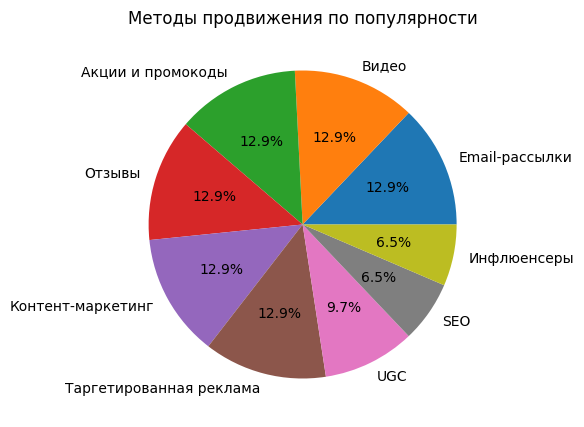

In [22]:
import matplotlib.pyplot as plt

top_methods = df_methods[df_methods['sources_count'] > 0]
plt.figure(figsize=(8, 5))
plt.pie(top_methods['sources_count'], labels=top_methods['method'], autopct='%1.1f%%')
plt.title('Методы продвижения по популярности')
plt.show()

🐾На основании 4х источников **контент-маркетинг, таргетированная реклама,отзыввы на различных площадках, видео в соц сетях, email-рассылки и акции** наиболее популярные маркетинговые ходы, поэтому наша компания будет делаь упор на этих видах рекламы и продвижения, однако, на другие опции тоже буту входить в наш план маркетинговой кампаниии